# Lab 4 — MNIST: Learning at Scale

## Task A — Reading the data

MNIST files use the IDX format: a big-endian header followed by raw unsigned bytes.
Label files have an 8-byte header (magic number, count); image files have a 16-byte
header (magic number, count, rows, cols). We skip the header and read the rest as `uint8`.

In [4]:
from pathlib import Path

import numpy as np

DATA_DIR = Path.cwd()
IMAGE_SIZE = 28

def read_labels(filename):
    data = (DATA_DIR / filename).read_bytes()
    return np.frombuffer(data, dtype=np.uint8, offset=8)

def read_images(filename):
    data = (DATA_DIR / filename).read_bytes()
    pixels = np.frombuffer(data, dtype=np.uint8, offset=16)
    return pixels.reshape(-1, IMAGE_SIZE, IMAGE_SIZE)

In [5]:
train_images = read_images("train-images-idx3-ubyte")
train_labels = read_labels("train-labels-idx1-ubyte")
test_images = read_images("t10k-images-idx3-ubyte")
test_labels = read_labels("t10k-labels-idx1-ubyte")

print("train:", train_images.shape, train_labels.shape)
print("test: ", test_images.shape, test_labels.shape)
print("labels:", np.unique(train_labels))
print("pixels:", train_images.min(), "to", train_images.max())
print("first labels:", train_labels[:10])

train: (60000, 28, 28) (60000,)
test:  (10000, 28, 28) (10000,)
labels: [0 1 2 3 4 5 6 7 8 9]
pixels: 0 to 255
first labels: [5 0 4 1 9 2 1 3 1 4]


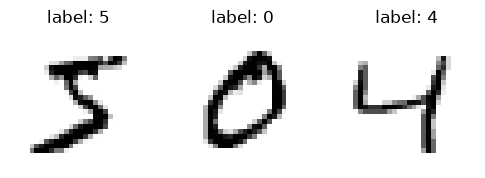

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(6, 2.5))
for i, ax in enumerate(axes):
    ax.imshow(train_images[i], cmap="gray_r")
    ax.set_title(f"label: {train_labels[i]}")
    ax.axis("off")
plt.show()

### Curating the data

The network expects one row per example, so each 28×28 image is flattened to 784 inputs
and scaled from 0–255 down to 0–1. Each label becomes a one-hot vector of length 10 to match
the 10 softmax outputs (e.g. `3` → `[0,0,0,1,0,0,0,0,0,0]`).

In [ ]:
NUM_CLASSES = 10


# Normalizing inputs
def to_inputs(images):
    return images.reshape(len(images), -1) / 255.0

# For softmax targets
def to_one_hot(labels):
    return np.eye(NUM_CLASSES)[labels]


train_inputs, train_targets = to_inputs(train_images), to_one_hot(train_labels)
test_inputs, test_targets = to_inputs(test_images), to_one_hot(test_labels)

print("inputs: ", train_inputs.shape, train_inputs.min(), "to", train_inputs.max())
print("targets:", train_targets.shape)
print("label", train_labels[0], "->", train_targets[0])

inputs:  (60000, 784) 0.0 to 1.0
targets: (60000, 10)
label 5 -> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Task C — Hyper-parameters

Network: `784 inputs -> hidden (ReLU) -> 10 outputs (softmax)`, trained with cross-entropy on
shuffled mini-batches. Training stops at the first epoch that reaches the goal: **≥ 99% training
accuracy** and **≥ 97% test accuracy** (at most 3% wrong).

`build_network` takes the hidden size and the range the initial weights are drawn from, so the
same helper covers every experiment in (1)–(4).

In [ ]:
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from neural_network_np.activations import ACTIVATIONS
from neural_network_np.hyperparameters import random_weights, zero_bias
from neural_network_np.layer import Layer
from neural_network_np.network import Network
from trainer_np.cost import COSTS
from trainer_np.trainer import Trainer

INPUT_SIZE = IMAGE_SIZE * IMAGE_SIZE
BATCH_SIZE = 32
TARGET_ACCURACY = 0.99
TARGET_TEST_ACCURACY = 0.97


def build_network(hidden_size, weight_range=(-0.05, 0.05), seed=0):
    np.random.seed(seed)
    low, high = weight_range

    hidden_layer = Layer.build(
        input_size=INPUT_SIZE, output_size=hidden_size,
        weight=random_weights(INPUT_SIZE, hidden_size, low, high),
        bias=zero_bias(hidden_size),
        activation_function=ACTIVATIONS.RELU.function,
        activation_derivative=ACTIVATIONS.RELU.derivative
    )
    output_layer = Layer.build(
        input_size=hidden_size, output_size=NUM_CLASSES,
        weight=random_weights(hidden_size, NUM_CLASSES, low, high),
        bias=zero_bias(NUM_CLASSES),
        activation_function=ACTIVATIONS.SOFTMAX.function,
        activation_derivative=ACTIVATIONS.SOFTMAX.derivative
    )
    
    return Network(hidden_layer, output_layer)


# the test set is passed as validation data: it is evaluated every epoch but never trained on
def train_network(network, learning_rate, train_x=train_inputs, test_x=test_inputs, max_epochs=20):
    trainer = Trainer(
        network,
        learning_rate=learning_rate,
        cost=COSTS.CROSS_ENTROPY,
        max_epochs=max_epochs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        report_interval=1
    )
    trainer.train(
        train_x,
        train_targets,
        test_x,
        test_targets,
        target_accuracy=TARGET_ACCURACY,
        target_validation_accuracy=TARGET_TEST_ACCURACY
    )
    return trainer

### Best set-up

A small sweep (hidden size 100/300, learning rate 0.3/0.5, batch size 16/32/64) found this
combination reaches the goal in the fewest epochs: **300 hidden units, weights in ±0.05,
learning rate 0.3**.

In [9]:
BEST_HIDDEN_SIZE = 300
BEST_WEIGHT_RANGE = (-0.05, 0.05)
BEST_LEARNING_RATE = 0.3

best_network = build_network(BEST_HIDDEN_SIZE, BEST_WEIGHT_RANGE)
best_trainer = train_network(best_network, BEST_LEARNING_RATE)

Epoch: 1/20 | Error: 0.2309 | Accuracy: 93.03% | Val Error: 0.1099 | Val Accuracy: 96.56%
Epoch: 2/20 | Error: 0.0910 | Accuracy: 97.27% | Val Error: 0.0928 | Val Accuracy: 97.16%
Epoch: 3/20 | Error: 0.0623 | Accuracy: 98.08% | Val Error: 0.0738 | Val Accuracy: 97.80%
Epoch: 4/20 | Error: 0.0446 | Accuracy: 98.59% | Val Error: 0.0705 | Val Accuracy: 97.88%
Epoch: 5/20 | Error: 0.0327 | Accuracy: 99.01% | Val Error: 0.0762 | Val Accuracy: 97.84%
Training completed.

Final Epoch:
Epoch: 5/20 | Error: 0.0327 | Accuracy: 99.01% | Val Error: 0.0762 | Val Accuracy: 97.84%
